In [5]:
import pandas as pd
orders=pd.read_csv("olist_orders_dataset.csv")
order_items=pd.read_csv("olist_order_items_dataset.csv")
payments=pd.read_csv("olist_order_payments_dataset.csv")
customers=pd.read_csv("olist_customers_dataset.csv")

CREATE SQL DATABASE

In [7]:
import sqlite3
conn=sqlite3.connect("olist.db")
orders.to_sql("orders",conn,if_exists="replace",index=False)
order_items.to_sql("order_items",conn,if_exists="replace",index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)

99441

CHECK TABLES

In [11]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,orders
1,order_items
2,payments
3,customers


TOTAL REVENUE

In [12]:
query = """
SELECT SUM(payment_value) AS total_revenue
FROM payments
"""
pd.read_sql(query, conn)

,total_revenue
0,1.600887e+07


TOTAL ORDERS

In [13]:
query = """
SELECT COUNT(DISTINCT order_id) AS total_orders
FROM orders
"""
pd.read_sql(query, conn)

,total_orders
0,99441


MONTHLY REVENUE

In [14]:
query = """
SELECT strftime('%Y-%m', order_purchase_timestamp) AS month,
       SUM(payment_value) AS revenue
FROM orders
JOIN payments USING(order_id)
GROUP BY month
ORDER BY month
"""
monthly_rev = pd.read_sql(query, conn)
monthly_rev

,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


VISUALIZE

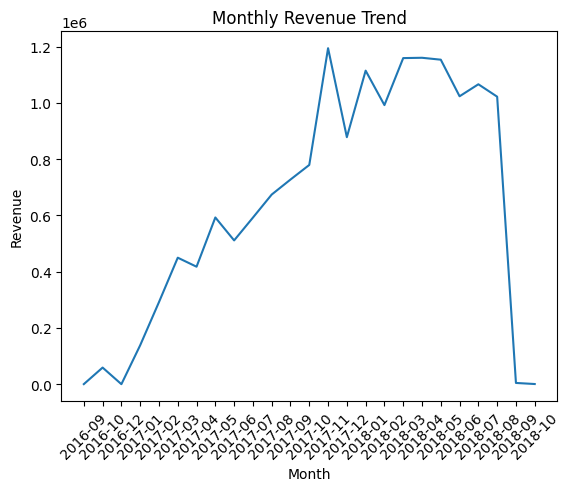

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_rev['month'], monthly_rev['revenue'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

TOP STATES

In [17]:
query = """
SELECT customer_state, SUM(payment_value) AS revenue
FROM customers
JOIN orders USING(customer_id)
JOIN payments USING(order_id)
GROUP BY customer_state
ORDER BY revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,customer_state,revenue
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


TOP PRODUCTS

In [18]:
query = """
SELECT product_id, SUM(price) AS revenue
FROM order_items
GROUP BY product_id
ORDER BY revenue DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,product_id,revenue
0,bb50f2e236e5eea0100680137654686c,63885.00
1,6cdd53843498f92890544667809f1595,54730.20
2,d6160fb7873f184099d9bc95e30376af,48899.34
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51
4,99a4788cb24856965c36a24e339b6058,43025.56
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60
6,25c38557cf793876c5abdd5931f922db,38907.32
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90
8,53b36df67ebb7c41585e8d54d6772e08,37683.42
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90


AVERAGE ORDER VALUE

In [19]:
query = """
SELECT
    SUM(payment_value) / COUNT(DISTINCT orders.order_id) AS avg_order_value
FROM orders
JOIN payments USING(order_id)
"""
pd.read_sql(query, conn)

,avg_order_value
0,160.990267


### Key Insights

- Revenue shows growth trend over months
- Certain states contribute highest revenue
- Few products dominate sales (Pareto effect)
- Average order value indicates customer spending behavior

### Business Recommendations

- Focus marketing on top-performing states
- Promote high-revenue products
- Improve low-performing regions

CUSTOMER SEGMENTATION

In [20]:
query = """
SELECT
    customer_id,
    SUM(payment_value) AS total_spent
FROM orders
JOIN payments USING(order_id)
GROUP BY customer_id
ORDER BY total_spent DESC
"""
customer_spend = pd.read_sql(query, conn)
customer_spend.head()

,customer_id,total_spent
0,1617b1357756262bfa56ab541c47bc16,13664.08
1,ec5b2ba62e574342386871631fafd3fc,7274.88
2,c6e2731c5b391845f6800c97401a43a9,6929.31
3,f48d464a0baaea338cb25f816991ab1f,6922.21
4,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66


CREATE SEGMENTS

In [21]:
customer_spend['segment'] = pd.qcut(customer_spend['total_spent'], 3, labels=['Low', 'Medium', 'High'])
customer_spend.head()

,customer_id,total_spent,segment
0,1617b1357756262bfa56ab541c47bc16,13664.08,High
1,ec5b2ba62e574342386871631fafd3fc,7274.88,High
2,c6e2731c5b391845f6800c97401a43a9,6929.31,High
3,f48d464a0baaea338cb25f816991ab1f,6922.21,High
4,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,High


VISUALIZE

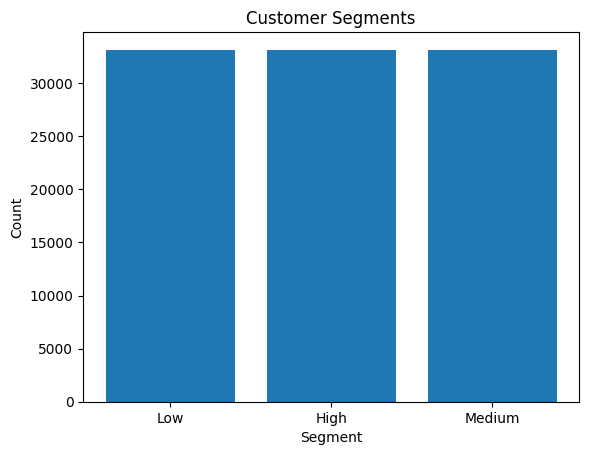

In [22]:
import matplotlib.pyplot as plt

segment_counts = customer_spend['segment'].value_counts()

plt.figure()
plt.bar(segment_counts.index, segment_counts.values)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()

- A small percentage of customers contribute majority of revenue
- High-value customers are key drivers of business growth

COHORT ANALYSIS

In [23]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['cohort_month'] = orders.groupby('customer_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

RETENTION TABLE

In [24]:
cohort_data = orders.groupby(['cohort_month', 'order_month'])['customer_id'].nunique().reset_index()

cohort_pivot = cohort_data.pivot(index='cohort_month', columns='order_month', values='customer_id')
cohort_pivot

order_month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,2018-10
cohort_month,,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,NaN,324.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-12,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,NaN,NaN,NaN,800.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-02,NaN,NaN,NaN,NaN,1780.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-03,NaN,NaN,NaN,NaN,NaN,2682.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-04,NaN,NaN,NaN,NaN,NaN,NaN,2404.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3700.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3245.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- Customer retention drops after first purchase
- Repeat purchase behavior is limited

## 📊 E-Commerce Analytics Project (Olist Dataset)

This project analyzes customer behavior, revenue trends, and product performance using SQL and Python.

The goal is to derive actionable business insights to improve revenue, customer retention, and overall performance.

## 📂 Data Tables Used

- orders → Contains order-level information
- order_items → Product-level details per order
- payments → Payment transactions and revenue
- customers → Customer demographic and location data

## 🛠️ SQL Analysis

Key SQL operations performed:

- Total revenue calculation
- Order count analysis
- Monthly revenue trends
- Revenue by customer location
- Top-performing products

## 📈 Visualizations

- Monthly revenue trend analysis
- Regional revenue comparison
- Customer segment distribution

## 👥 Customer Segmentation

Customers were segmented into:

- Low-value customers
- Medium-value customers
- High-value customers

This helps identify key revenue-driving users and target them effectively.

## 🔁 Cohort Analysis

Cohort analysis was performed to track customer retention over time.

It helps understand repeat purchase behavior and customer lifecycle trends.

## 🧠 Key Insights

- Revenue shows a growing trend over time
- Certain regions contribute significantly to total revenue
- A small group of customers generates a large portion of revenue
- Customer retention decreases after the first purchase

## 💡 Business Recommendations

- Focus marketing on high-performing regions
- Target high-value customers with loyalty programs
- Improve retention strategies (discounts, follow-ups)
- Promote top-selling products to maximize revenue